#PCA
stands for PRINCIPAL COMPONENT ANALYSIS. its an unsupervised machine learning algorithm used for dimensionality reduction. we dont need target variable in pca

Dimension meand columns or features in python. 30 columns gives 95% and 94% but if i get the same accuracy in 5 columns why do we need 25 columns.

why dimension reduction?
if we have more no of dimenstion we will get overfit to reduce overfit we need to reduce dimension/features

in what scenario we will go for dimension reduction?
1. when you have columns with more no of blank values we drop the column
2. if there is strong relationship between x and x drop eother of them
3. columns having low variance
4. regularisation(lasso+elasricnet)

how pca formed?
plot graph age vs height and you draw straight line. dimension of this data is 2d. after applying PCA . all the datapoint should be on single axis

FEATURE ENGINEERING. is a process to use domain knowledge to extract meaningful information form the raw data
1. feature transformation(handling missing values, handling categorical variable, handling outliers, feature scaling)#
2. feature construction
1+2---- single column

3. feature slection:
10 features---6 features

4. feature extraction: u r creating new columns based on the existing one without changing its behaviour PCA feature extraction

#ASSIGNMENT

PCA
Task 1: Exploratory Data Analysis (EDA):  
1.	Load the dataset and perform basic data exploration.  
2.	Examine the distribution of features using histograms, box plots, or density plots.  
3.	Investigate correlations between features to understand relationships within the data.  
Task 2: Dimensionality Reduction with PCA:  
1.	Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the dataset.  
2.	Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.  
3.	Transform the original dataset into the principal components.  
Task 3: Clustering with Original Data:  
1.	Apply a clustering algorithm (e.g., K-means) to the original dataset.  
2.	Visualize the clustering results using appropriate plots.  
3.	Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index.  
Task 4: Clustering with PCA Data:  
1.	Apply the same clustering algorithm to the PCA-transformed dataset.  
2.	Visualize the clustering results obtained from PCA-transformed data.  
3.	Compare the clustering results from PCA-transformed data with those from the original dataset.  
Task 5: Comparison and Analysis:  
1.	Compare the clustering results obtained from the original dataset and PCA-transformed data.  
2.	Discuss any similarities or differences observed in the clustering results.  
3.	Reflect on the impact of dimensionality reduction on clustering performance.  
4.	Analyze the trade-offs between using PCA and clustering directly on the original dataset.   
Task 6: Conclusion and Insights  

1.	Summarize the key findings and insights from the assignment.  
2.	Discuss the practical implications of using PCA and clustering in data analysis.  
3.	Provide recommendations for when to use each technique based on the analysis conducted.  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/wine.csv')
df

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [ ]:
df.shape

(178, 14)

In [ ]:
df.size

2492

In [ ]:
df.isnull().sum()

,0
Type,0
Alcohol,0
Malic,0
Ash,0
Alcalinity,0
Magnesium,0
Phenols,0
Flavanoids,0
Nonflavanoids,0
Proanthocyanins,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [ ]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


<Axes: ylabel='Frequency'>

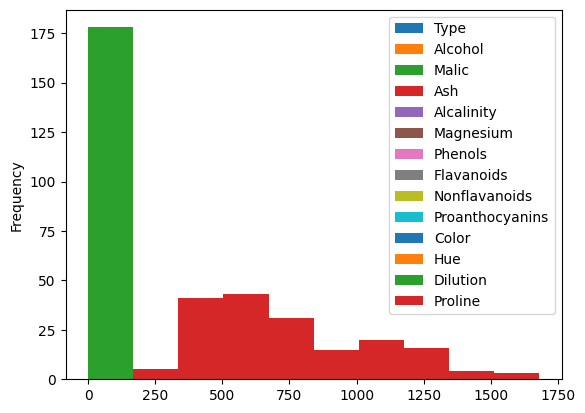

In [ ]:
df.plot(kind='hist') #the data is right skewed there are outliers

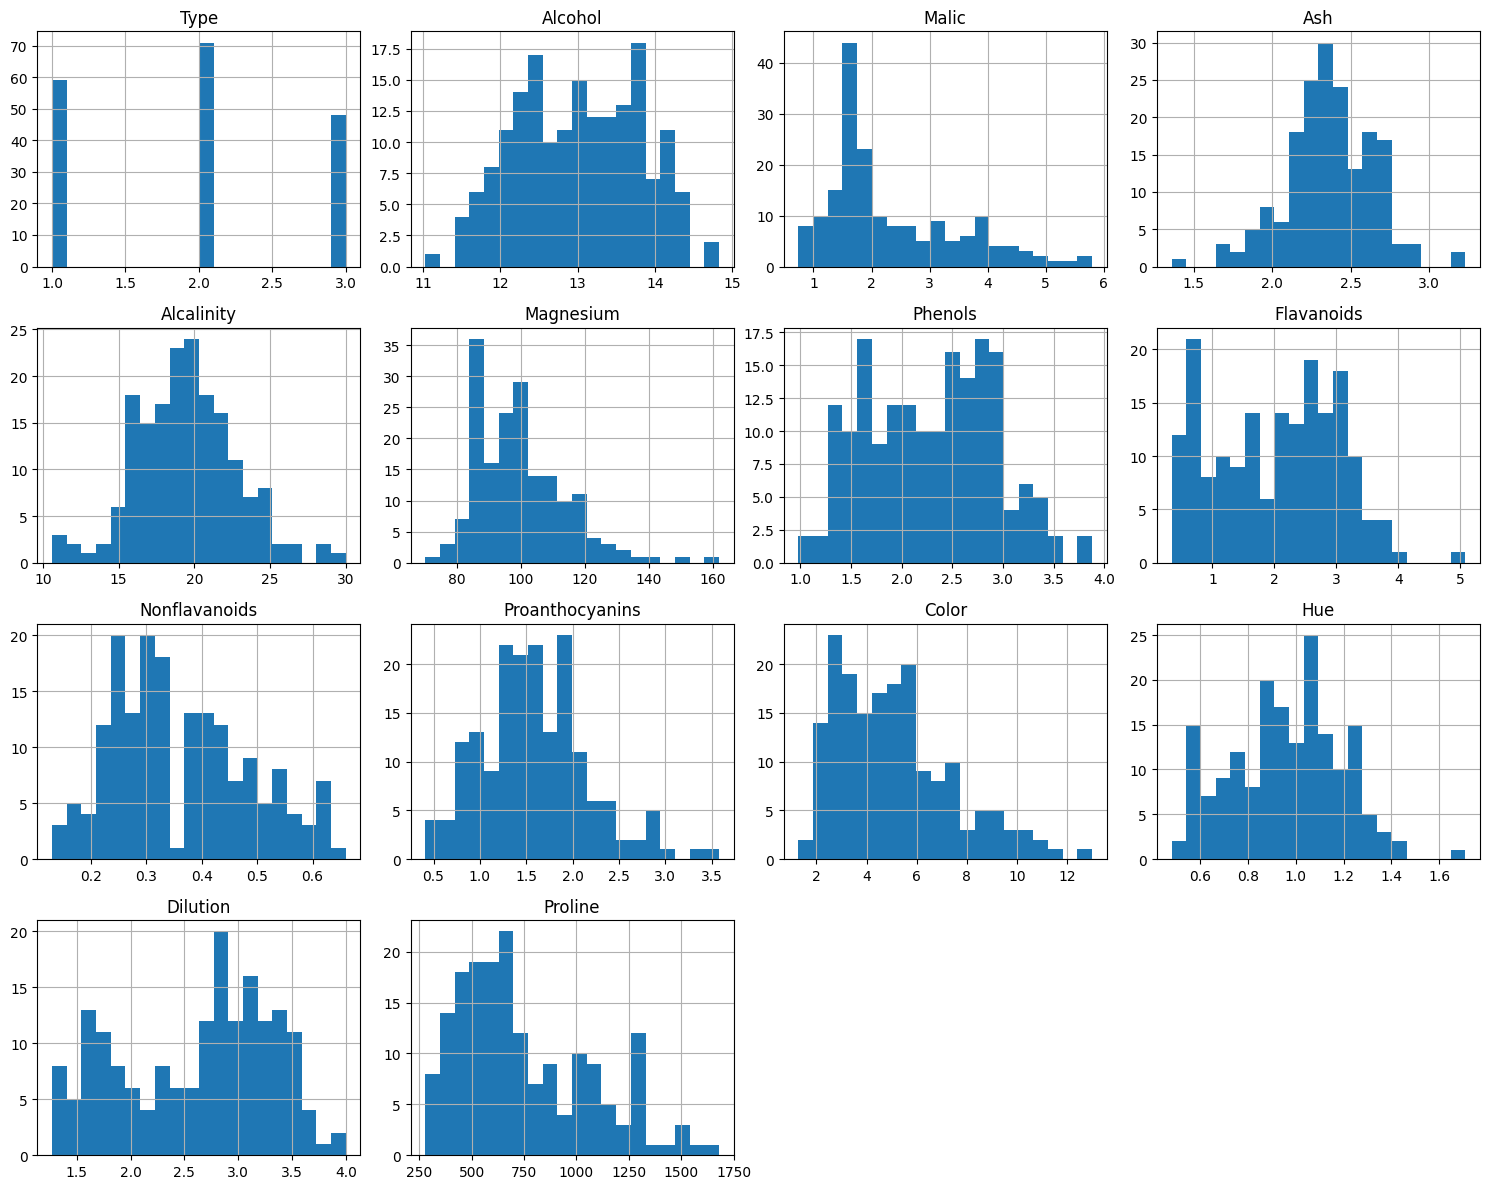

In [ ]:
df.hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.show() # or simply do df.hist(figsize=(12,10)) plt.show() several features show skewed distribution. some variabkes contain outliers like Malic colors and proline
#Feature scales vary significantly, indicating the need for standardization before PCA and clustering.

In [ ]:
#correlation matrics
corr_matrics=df.corr()

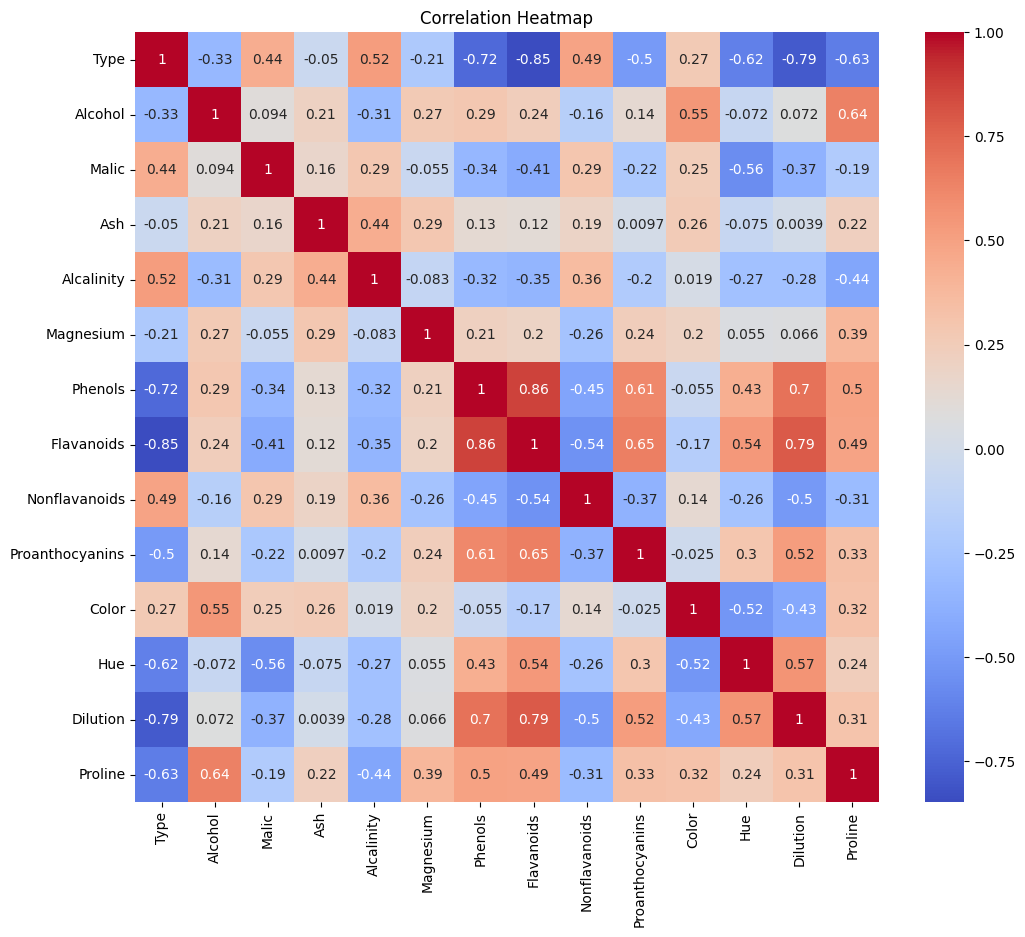

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrics, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
#storn relationship between flavanoids and phenols. flavanoids and dilusion

In [ ]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('Type', axis=1)
y=df['Type']

In [ ]:
X

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [ ]:
y #what id there are 3 features in y like here its  1,2,3 and in class it was just M and F that we convert it to binary

,Type
0,1
1,1
2,1
3,1
4,1
...,...
173,3
174,3
175,3
176,3


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_sc=sc.fit_transform(X)
x_sc=pd.DataFrame(x_sc)
x_sc.columns=X.columns
x_sc


,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.876275,2.974543,0.305159,0.301803,-0.332922,-0.985614,-1.424900,1.274310,-0.930179,1.142811,-1.392758,-1.231206,-0.021952
174,0.493343,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.549108,-0.316950,0.969783,-1.129518,-1.485445,0.009893
175,0.332758,1.744744,-0.389355,0.151661,1.422412,-1.129824,-1.344582,0.549108,-0.422075,2.224236,-1.612125,-1.485445,0.280575
176,0.209232,0.227694,0.012732,0.151661,1.422412,-1.033684,-1.354622,1.354888,-0.229346,1.834923,-1.568252,-1.400699,0.296498


In [ ]:
from sklearn.decomposition import PCA
pca=PCA()
x_pc=pca.fit_transform(x_sc)
x_pc=pd.DataFrame(x_pc)
x_pc

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,3.316751,1.443463,-0.165739,-0.215631,0.693043,0.223880,0.596427,-0.065139,-0.641443,1.020956,-0.451563,0.540810,-0.066239
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655,0.927120,0.053776,-1.024416,0.308847,0.159701,-0.142657,0.388238,0.003637
2,2.516740,1.031151,0.982819,0.724902,-0.251033,-0.549276,0.424205,0.344216,1.177834,0.113361,-0.286673,0.000584,0.021717
3,3.757066,2.756372,-0.176192,0.567983,-0.311842,-0.114431,-0.383337,-0.643593,-0.052544,0.239413,0.759584,-0.242020,-0.369484
4,1.008908,0.869831,2.026688,-0.409766,0.298458,0.406520,0.444074,-0.416700,-0.326819,-0.078366,-0.525945,-0.216664,-0.079364
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,-3.370524,2.216289,-0.342570,1.058527,-0.574164,1.108788,0.958416,0.146097,0.022498,-0.304117,0.139228,0.170786,-0.114427
174,-2.601956,1.757229,0.207581,0.349496,0.255063,0.026465,0.146894,0.552427,0.097969,-0.206061,0.258198,-0.279431,-0.187371
175,-2.677839,2.760899,-0.940942,0.312035,1.271355,-0.273068,0.679235,-0.047024,-0.001222,-0.247997,0.512492,0.698766,0.072078
176,-2.387017,2.297347,-0.550696,-0.688285,0.813955,-1.178783,0.633975,-0.390829,-0.057448,0.491490,0.299822,0.339821,-0.021866


In [ ]:
x_pc.var()

,0
0,4.732437
1,2.511081
2,1.454242
3,0.924166
4,0.858049
5,0.645282
6,0.554141
7,0.350466
8,0.290512
9,0.252320


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(x_sc)

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(x_sc, clusters)

print(score)

0.2848589191898987


In [ ]:
pca = PCA(n_components=2)

X_pc = pca.fit_transform(x_sc)

kmeans_pca = KMeans(n_clusters=3, random_state=42)

clusters_pca = kmeans_pca.fit_predict(X_pc)

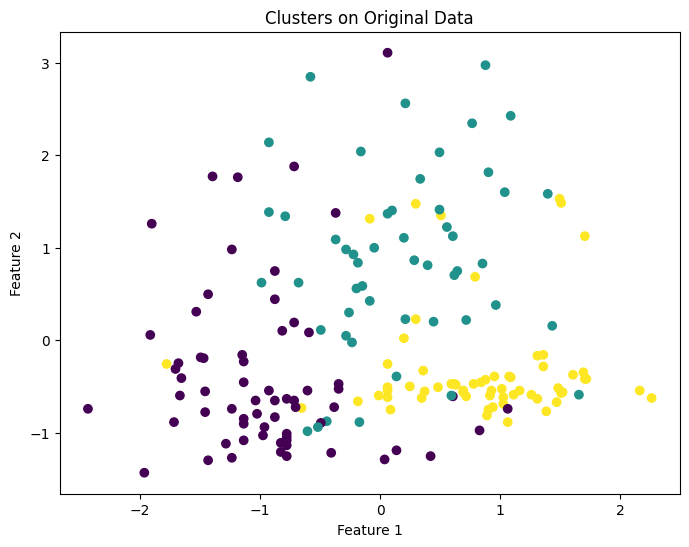

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(x_sc.iloc[:,0], x_sc.iloc[:,1],
            c=clusters,
            cmap='viridis')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Clusters on Original Data")
plt.show()

The clusters obtained after PCA are more clearly separated than those obtained using the original dataset. PCA removes redundant information and makes visualization easier while preserving most of the important information.

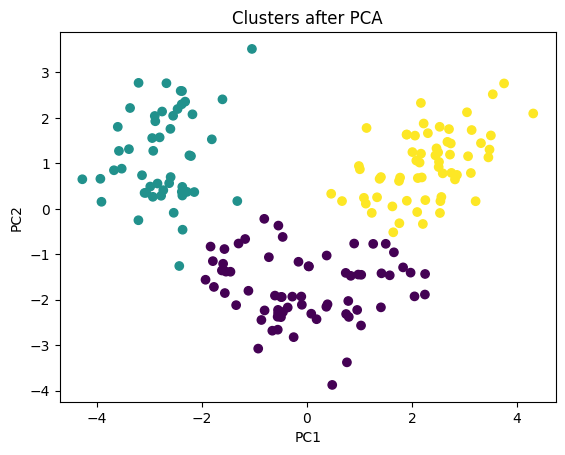

In [ ]:
plt.scatter(x_pc.iloc[:,0], x_pc.iloc[:,1], c=clusters_pca)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters after PCA")
plt.show()

PCA reduces the number of features.
Clustering becomes easier to visualize.
The clustering results remain similar.

The Wine dataset contains correlated features.
PCA reduced the dimensionality while preserving most of the information.
K-Means clustering worked well on both the original and PCA-transformed data.
PCA made the clustering easier to visualize and slightly improved efficiency.